<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Exploration of soil moisture for cells in different HC classes
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p><strong>Each grid cell in the UK is classified according to its hydraulic conductivity.</strong></p>
   <ul>      
        <li> **Low HC**: very impermeable soils (e.g., clay) </li>
        <li> **Medium HC**: moderately permeable soils (e.g., loam) </li>
        <li> **High HC**: very permeable soils (e.g., sand/gravel) </li>
        </ul>

  <p><strong>Why am I doing this?:</strong></p>
  <ul>
    <li> In AnalyseResults.ipynb compare the antecedent conditions of events happening on clay vs. sandy soils </li>
    <li> Want to know whether those differences are to do with something about the events themselves or just to do with the antecedent conditions on those soils </li>
  </ul>    
    
    
  <p><strong>This script tests:</strong></p>
  <ul>
<!--     <li>The number of events per catchment, per ensemble member with an unphysical value</li>
    <li>The number of pixels affected per event</li> -->
  </ul>

</div>

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
from tqdm import tqdm
import glob
import matplotlib.gridspec as gridspec
import pickle

ENSEMBLE_MEMBERS = ['01', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '15']

SOIL_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
CATCHMENT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/CatchmentShapefiles/"
catchments = gpd.read_file(CATCHMENT_DIR + "hyd_areas_GB_with_subcatchments.shp")

HA_NUM = 2

from run_HC_conversion import aggregate_to_5km, convert_to_netcdf, filter_closer_to_catchment

### Join together the Hydraulic Conductivity data for each catchment - one file for whole country

In [2]:
ha_nums = catchments['HA_NUM'].unique()

# Load first cube to get the shape/metadata as template
first = iris.load(f"../../Data/HydraulicConductivity/5km_{ha_nums[0]}.nc")[0]
national_data = np.full(first.shape, np.nan, dtype=np.float32)

for ha_num in tqdm(ha_nums):
    hk_in = iris.load(f"../../Data/HydraulicConductivity/5km_{ha_num}.nc")[0]
    data = hk_in.data  # numpy array or masked array
    
    # Handle masked arrays
    if np.ma.is_masked(data):
        valid = ~data.mask
    else:
        valid = ~np.isnan(data)
    
    # Only fill where this catchment has data and national is still empty
    national_data[valid] = data[valid]

# Put back into a cube using the first cube as template
national_cube = first.copy(data=national_data)
national_cube.rename("hydraulic_conductivity")

print(national_cube)
print(f"Valid cells: {np.sum(~np.isnan(national_data))}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 114/114 [02:40<00:00,  1.40s/it]

hydraulic_conductivity / (m/day)    (projection_y_coordinate: 244; projection_x_coordinate: 180)
    Dimension coordinates:
        projection_y_coordinate                             x                             -
        projection_x_coordinate                             -                             x
    Attributes:
        description                 'Mean hydraulic conductivity aggregated from 30m to 5km'
Valid cells: 10239


In [3]:
# qplt.pcolormesh(national_cube)

In [4]:
# Define bins — adjust edges based on the percentile output above
bin_edges  = [0, 0.3, 0.7, 1.0]  # or whatever makes sense for your hk range
bin_labels = ["low (0-0.3)", "mid (0.3-0.7)", "high (0.7-1.0)"]

In [5]:
hk_data = national_cube.data  # (244, 180)

# Handle masked arrays
if np.ma.is_masked(hk_data):
    hk_vals = hk_data.filled(np.nan)
else:
    hk_vals = hk_data

bin_edges  = [0, 0.3, 0.7, 1.0]   # adjust to your HK range
bin_labels = ["low (0–0.3)", "mid (0.3–0.7)", "high (0.7–1.0)"]

# (244, 180) — integer 1/2/3, 0 = outside all bins
hk_bin_idx = np.digitize(hk_vals, bins=bin_edges, right=True)

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot seasonal cycle in soil moisture (across all EMs and all years [1980-2080]) </h3>
</div>

In [6]:
# sm_data shape is (360, 244, 180) per year — collect across years first

if os.path.exists('../../Data/SoilInfo/all_years_data.pickle'):
    print("Reading from file")
    with open('../../Data/SoilInfo/all_years_data.pickle', 'rb') as handle:
        all_years_data = pickle.load(handle)

else:        
    all_years_data = {label: [] for label in bin_labels}

    for ens in ENSEMBLE_MEMBERS:
        sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'
        for year in tqdm(range(1980, 2080)):
            try:
                sm_file = glob.glob(
                    f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc"
                )[0]
            except IndexError:
                continue

            sm_yr = iris.load(sm_file)[0]
            sm_arr = sm_yr.data.filled(np.nan) if np.ma.is_masked(sm_yr.data) else sm_yr.data

            for i, label in enumerate(bin_labels):
                mask = hk_bin_idx == (i + 1)
                # Mean over cells for each day -> (360,)
                all_years_data[label].append(np.nanmean(sm_arr[:, mask], axis=1))


Reading from file


In [14]:
colors = ["#2c7bb6", "#fdae61", "#d7191c"]

In [ ]:
# Plot climatological mean +/- std across years
fig, ax = plt.subplots(figsize=(14, 5))
days = np.arange(360)

for label, color in zip(bin_labels, colors):
    stack = np.stack(all_years_data[label], axis=0)  # (n_years, 360)
    clim_mean = np.nanmean(stack, axis=0)             # (360,)
    clim_std  = np.nanstd(stack,  axis=0)             # (360,)

    ax.plot(days, clim_mean, label=label, color=color)
    ax.fill_between(days,
                    clim_mean - clim_std,
                    clim_mean + clim_std,
                    alpha=0.15, color=color)

ax.set_xlabel("Day of year (Dec–Nov)")
ax.set_ylabel("Soil moisture (kg/m²)")
ax.set_title("Climatological daily SM by HC class, 1980–2020")
ax.legend(title="HC class (m/day)")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot  </h3>
</div>

In [33]:
if not os.path.isfile('../../Data/SoilInfo/yearly_sm_per_bin.csv'):
    print("Reading from file")
    df = pd.read_csv('../../Data/SoilInfo/yearly_sm_per_bin.csv')
else:
    print("creating")
    results = []
    for ens in ENSEMBLE_MEMBERS:
        sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'

        for year in tqdm(range(1980, 2080)):
            try:
                sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
            except IndexError:
                continue

            sm_arr = iris.load(sm_file)[0].data
            if np.ma.is_masked(sm_arr):
                sm_arr = sm_arr.filled(np.nan)

            for i, label in enumerate(bin_labels):
                mask = hk_bin_idx == (i + 1)
                results.append({
                    'em':ens, 
                    "year": year,
                    "hk_bin": label,
                    "mean_sm": np.nanmean(sm_arr[:, mask]),  # scalar — mean over all days & cells
                    "std_sm":  np.nanstd(sm_arr[:, mask]),})

        df = pd.DataFrame(results)
    df.to_csv('../../Data/SoilInfo/yearly_sm_per_bin.csv')

creating


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [04:56<00:00,  2.97s/it]


In [32]:
df

,em,year,hk_bin,mean_sm,std_sm
0,01,1981,low (0–0.3),73.660340,20.948655
1,01,1981,mid (0.3–0.7),73.515293,19.492425
2,01,1981,high (0.7–1.0),66.809469,22.579768
3,04,1981,low (0–0.3),74.650305,20.826828
4,04,1981,mid (0.3–0.7),73.219693,19.278824
5,04,1981,high (0.7–1.0),65.780593,22.539344
6,05,1981,low (0–0.3),76.431096,20.994205
7,05,1981,mid (0.3–0.7),74.725869,18.918055
8,05,1981,high (0.7–1.0),67.946358,21.885480
9,06,1981,low (0–0.3),73.766932,21.428111


In [12]:
if os.path.isfile('../../Data/SoilInfo/yearly_sm_seasonal_per_bin.csv'):
    print("Reading from file")
    df_seasonal = pd.read_csv('../../Data/SoilInfo/yearly_sm_seasonal_per_bin.csv')
else:
    print("Producing output")
    # Assuming Dec-Nov year: days 0-89=Dec-Feb, 90-179=Mar-May, etc.
    seasons = { "DJF (Dec-Feb)": slice(0,   90),
        "MAM (Mar-May)": slice(90,  180),
        "JJA (Jun-Aug)": slice(180, 270),
        "SON (Sep-Nov)": slice(270, 360),}

    results = []
    
    
    sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'
    
    for year in tqdm(range(1980, 2081)):
        try:
            sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
        except IndexError:
            continue

        sm_arr = iris.load(sm_file)[0].data
        if np.ma.is_masked(sm_arr):
            sm_arr = sm_arr.filled(np.nan)

        for i, label in enumerate(bin_labels):
            mask = hk_bin_idx == (i + 1)
            for season, sl in seasons.items():
                results.append({ "year": year, "hk_bin": label, "season": season, "mean_sm": np.nanmean(sm_arr[sl, mask])})

    df_seasonal = pd.DataFrame(results)
    df_seasonal.to_csv('../../Data/SoilInfo/yearly_sm_seasonal_per_bin.csv', index=False)

Reading from file


/tmp/ipykernel_28061/2869609140.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_full.legend(title="HC class")


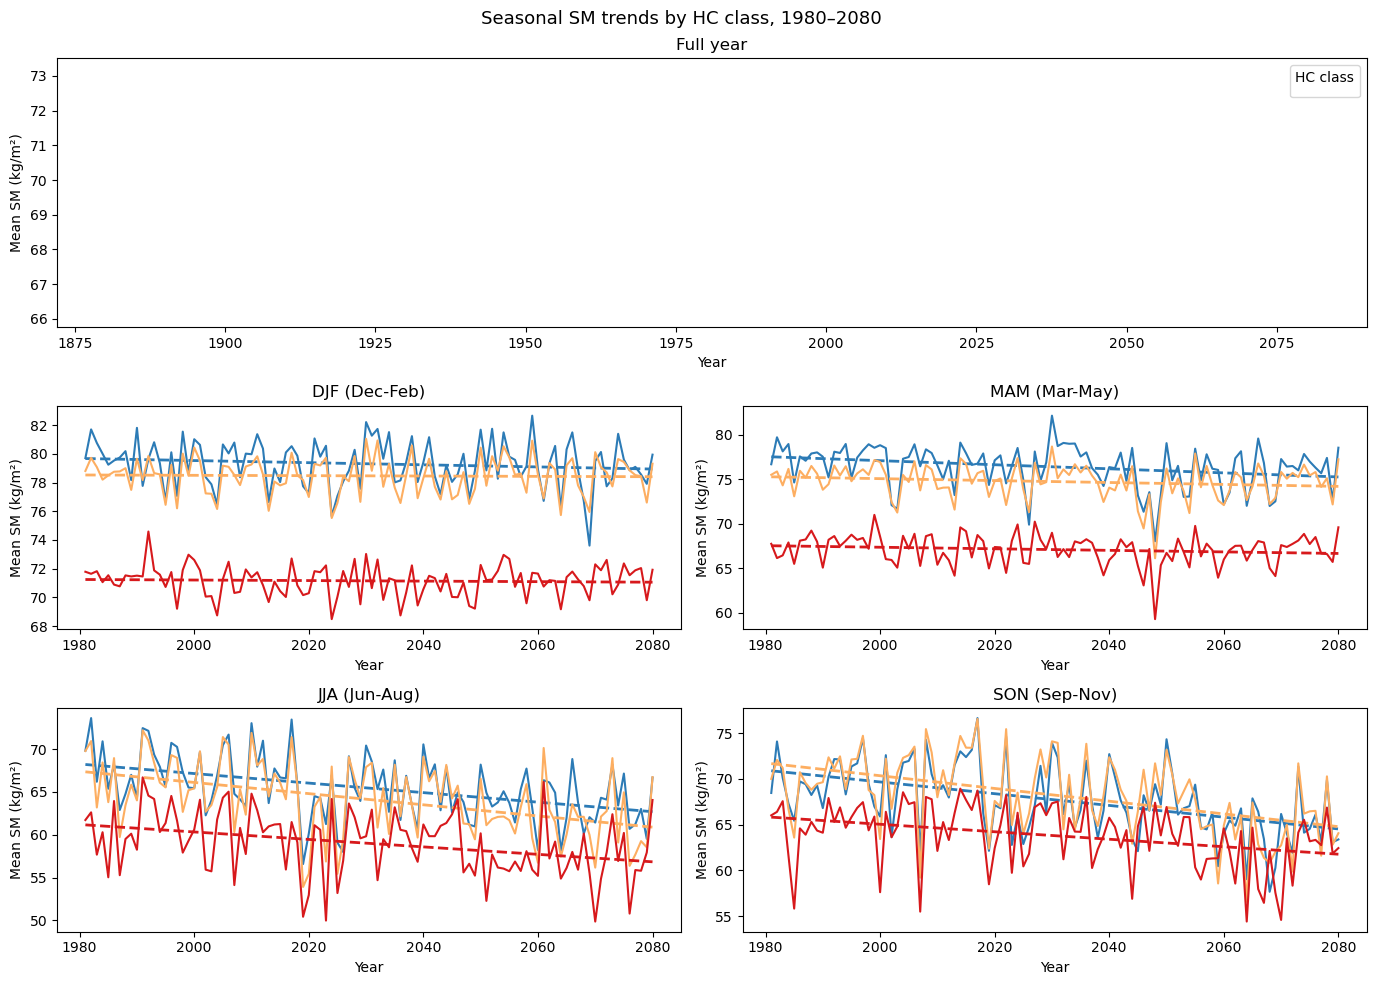

In [31]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 2, height_ratios=[1.2, 1, 1])

# ── TOP: FULL YEAR (spans both columns) ─────────────────────────────
ax_full = fig.add_subplot(gs[0, :])

for label, color in zip(bin_labels, colors):
    s = df[df["hk_bin"] == label]
    s_year = s.groupby("year")["mean_sm"].mean().reset_index()
    ax_full.plot(s_year["year"], s_year["mean_sm"], color=color)
    
    # --- Fit trendline ---
    # (better to aggregate by year in case of duplicates)
    s_year = s.groupby("year")["mean_sm"].mean().reset_index()
    
    x = s_year["year"].values
    y = s_year["mean_sm"].values
    
    if len(x) > 1:  # avoid crashes
        m, b = np.polyfit(x, y, 1)
        label_with_slope = f"{label} (slope={m:.3f})"
        ax_full.plot(x, m*x + b, color=color, linestyle="--", linewidth=2, label =label)

ax_full.set_title("Full year")
ax_full.set_xlabel("Year")
ax_full.set_ylabel("Mean SM (kg/m²)")

# ── BOTTOM: SEASONAL 2x2 ────────────────────────────────────────────
axes = [fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[2, 1]),]

for ax, season in zip(axes, seasons.keys()):
    sub = df_seasonal[df_seasonal["season"] == season]
    
    for label, color in zip(bin_labels, colors):
        s = sub[sub["hk_bin"] == label]
        
        s_seasonal = s.groupby("year")["mean_sm"].mean().reset_index()
        x = s_seasonal["year"].values
        y = s_seasonal["mean_sm"].values
        if len(x) > 1:  # avoid crashes
            m, b = np.polyfit(x, y, 1)
            label_with_slope = f"{label} (slope={m:.3f})"
            ax.plot(x, m*x + b, color=color,
                    linestyle="--", linewidth=2)
            
        ax.plot(s["year"], s["mean_sm"], label=label, color=color)
    
    ax.set_title(season)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean SM (kg/m²)")

# legend only once
ax_full.legend(title="HC class")

plt.suptitle("Seasonal SM trends by HC class, 1980–2080", fontsize=13)
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot seasonal cycle in soil moisture (across all EMs and all years [1980-2080]) </h3>
</div>

In [32]:
periods = {"1980–2020": range(1980, 2020), "2020–2050": range(2020, 2050), "2050–2080": range(2050, 2080),}

# Accumulate daily means per bin per period
period_data = {period: {label: [] for label in bin_labels}
    for period in periods}

for period, years in periods.items():
    for year in tqdm(years, desc=period):
        try:
            sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
        except IndexError:
            continue

        sm_arr = iris.load(sm_file)[0].data
        if np.ma.is_masked(sm_arr):
            sm_arr = sm_arr.filled(np.nan)

        for i, label in enumerate(bin_labels):
            mask = hk_bin_idx == (i + 1)
            period_data[period][label].append(
                np.nanmean(sm_arr[:, mask], axis=1))

2050–2080: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [02:14<00:00,  4.47s/it]


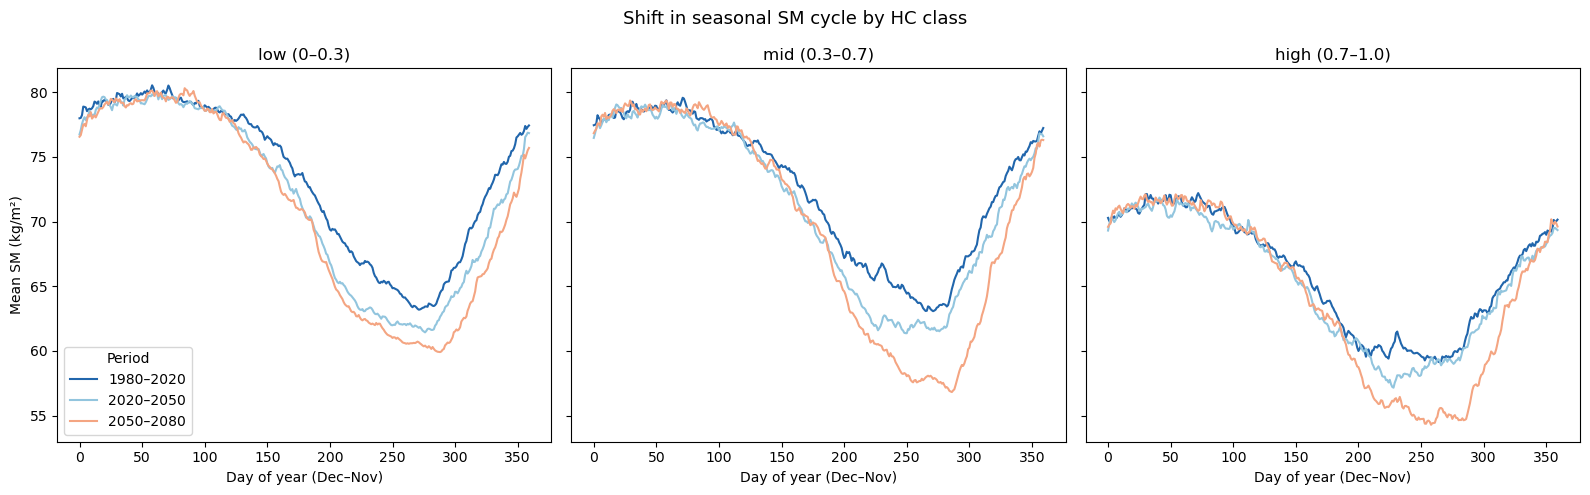

In [35]:
# Plot seasonal cycle per bin, coloured by period
period_colors = ["#2166ac", "#92c5de", "#f4a582", "#d6604d"]
days = np.arange(360)

fig, axes = plt.subplots(1, len(bin_labels), figsize=(16, 5), sharey=True)

for ax, label in zip(axes, bin_labels):
    for (period, p_color) in zip(periods.keys(), period_colors):
        stack = np.stack(period_data[period][label], axis=0)  # (n_years, 360)
        clim  = np.nanmean(stack, axis=0)                     # (360,)
        ax.plot(days, clim, label=period, color=p_color)

    ax.set_title(label)
    ax.set_xlabel("Day of year (Dec–Nov)")

axes[0].set_ylabel("Mean SM (kg/m²)")
axes[0].legend(title="Period")
plt.suptitle("Shift in seasonal SM cycle by HC class", fontsize=13)
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot seasonal cycle in soil moisture (across all EMs and all years [1980-2080]) </h3>
</div>

In [42]:
low = df[df['hk_bin']=='low (0–0.3)']
med = df[df['hk_bin']=='mid (0.3–0.7)']
high = df[df['hk_bin']=='high (0.7–1.0)']

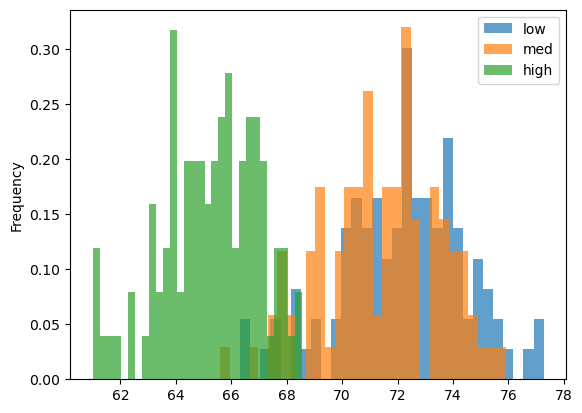

In [47]:
fig, ax = plt.subplots()
low['mean_sm'].plot.hist(ax=ax,alpha=0.7,bins=30,density=True, label = "low")
med['mean_sm'].plot.hist(ax=ax,alpha=0.7,bins=30,density=True, label= 'med')
high['mean_sm'].plot.hist(ax=ax,alpha=0.7,bins=30,density=True, label = 'high')
ax.legend()